In [13]:
import numpy as np
import pandas as pd
import time
import threading
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import psutil
import os

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [14]:
class CPUMonitor:
    """Мониторинг загрузки CPU во время выполнения"""
    
    def __init__(self, interval=1.0):
        self.interval = interval
        self.monitoring = False
        self.cpu_data = []
        self.thread = None
    
    def start_monitoring(self):
        """Запуск мониторинга в отдельном потоке"""
        self.monitoring = True
        self.cpu_data = []
        self.thread = threading.Thread(target=self._monitor_loop)
        self.thread.daemon = True
        self.thread.start()
    
    def _monitor_loop(self):
        """Цикл мониторинга"""
        while self.monitoring:
            timestamp = time.time()
            cpu_percent = psutil.cpu_percent(interval=self.interval, percpu=True)
            self.cpu_data.append({
                'timestamp': timestamp,
                'cpu_percent': cpu_percent,
                'total_usage': sum(cpu_percent) / len(cpu_percent)
            })
    
    def stop_monitoring(self):
        """Остановка мониторинга"""
        self.monitoring = False
        if self.thread:
            self.thread.join(timeout=2)
        return self.get_summary()
    
    def get_summary(self):
        """Получение сводки по использованию CPU"""
        if not self.cpu_data:
            return {}
        
        total_usage = [data['total_usage'] for data in self.cpu_data]
        cpu_cores_usage = []
        
        # Анализ по ядрам
        num_cores = len(self.cpu_data[0]['cpu_percent'])
        for core in range(num_cores):
            core_usage = [data['cpu_percent'][core] for data in self.cpu_data]
            cpu_cores_usage.append({
                'core': core,
                'avg_usage': np.mean(core_usage),
                'max_usage': np.max(core_usage),
                'min_usage': np.min(core_usage)
            })
        
        return {
            'duration_seconds': self.cpu_data[-1]['timestamp'] - self.cpu_data[0]['timestamp'],
            'total_avg_usage': np.mean(total_usage),
            'total_max_usage': np.max(total_usage),
            'total_min_usage': np.min(total_usage),
            'cores_usage': cpu_cores_usage,
            'sample_count': len(self.cpu_data)
        }


In [15]:
def get_system_info():
    """Получение информации о системе"""
    cpu_info = {
        'physical_cores': psutil.cpu_count(logical=False),
        'logical_cores': psutil.cpu_count(logical=True),
        'cpu_freq': psutil.cpu_freq()._asdict() if psutil.cpu_freq() else {},
        'cpu_percent': psutil.cpu_percent(interval=1)
    }
    
    memory_info = psutil.virtual_memory()._asdict()
    
    return {
        'cpu': cpu_info,
        'memory': memory_info,
        'timestamp': datetime.now().isoformat()
    }

system_info = get_system_info()
print(f"Система: {system_info['cpu']['logical_cores']} логических ядер")
print(f"Память: {system_info['memory']['total'] / (1024**3):.1f} ГБ")

Система: 72 логических ядер
Память: 503.7 ГБ


In [16]:
print("\n1. ЗАГРУЗКА ДАННЫХ MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Предобработка данных
X = X.astype('float32') / 255.0
y = y.astype(int)

# Разделение на train/test
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Данные загружены: {X_train.shape[0]} тренировочных, {X_test.shape[0]} тестовых образцов")

# Параметры тестирования
class Config:
    RF_ESTIMATORS = [50, 100, 200]
    MAX_DEPTH = 20
    NUM_RUNS = 3
    RANDOM_STATE = 42

config = Config()


1. ЗАГРУЗКА ДАННЫХ MNIST...
Данные загружены: 60000 тренировочных, 10000 тестовых образцов


In [17]:
def benchmark_random_forest_with_monitoring(X_train, y_train, X_test, y_test, n_estimators=100, max_depth=20):
    """Запуск бенчмарка для Random Forest с мониторингом CPU"""
    
    times = []
    accuracies = []
    cpu_monitor_data = []
    
    for run in range(config.NUM_RUNS):
        print(f"  Запуск {run + 1}/{config.NUM_RUNS}...")
        
        # Запуск мониторинга CPU
        cpu_monitor = CPUMonitor(interval=0.5)
        cpu_monitor.start_monitoring()
        
        start_time = time.perf_counter()
        
        # Создание и обучение модели
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=config.RANDOM_STATE + run,
            n_jobs=-1  # Использование всех ядер
        )
        
        rf.fit(X_train, y_train)
        training_time = time.perf_counter() - start_time
        
        # Остановка мониторинга и получение данных
        cpu_summary = cpu_monitor.stop_monitoring()
        
        # Оценка точности
        y_pred = rf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        times.append(training_time)
        accuracies.append(accuracy)
        cpu_monitor_data.append(cpu_summary)
        
        print(f"    Время: {training_time:.2f} сек, Точность: {accuracy:.4f}")
        print(f"    CPU usage: {cpu_summary.get('total_avg_usage', 0):.1f}%")
    
    return {
        'times': times,
        'accuracies': accuracies,
        'cpu_monitor_data': cpu_monitor_data,
        'avg_time': np.mean(times),
        'std_time': np.std(times),
        'avg_accuracy': np.mean(accuracies),
        'std_accuracy': np.std(accuracies),
        'avg_cpu_usage': np.mean([data.get('total_avg_usage', 0) for data in cpu_monitor_data])
    }


In [18]:
print("\n2. ЗАПУСК ТЕСТИРОВАНИЯ RANDOM FOREST С МОНИТОРИНГОМ CPU...")
results = {}

for n_est in config.RF_ESTIMATORS:
    print(f"\nТестирование с {n_est} деревьями:")
    
    result = benchmark_random_forest_with_monitoring(X_train, y_train, X_test, y_test, n_est, config.MAX_DEPTH)
    results[n_est] = result
    
    print(f"  Среднее время: {result['avg_time']:.2f} ± {result['std_time']:.2f} сек")
    print(f"  Средняя точность: {result['avg_accuracy']:.4f} ± {result['std_accuracy']:.4f}")
    print(f"  Средняя загрузка CPU: {result['avg_cpu_usage']:.1f}%")



2. ЗАПУСК ТЕСТИРОВАНИЯ RANDOM FOREST С МОНИТОРИНГОМ CPU...

Тестирование с 50 деревьями:
  Запуск 1/3...
    Время: 0.98 сек, Точность: 0.9655
    CPU usage: 45.3%
  Запуск 2/3...
    Время: 0.93 сек, Точность: 0.9646
    CPU usage: 43.3%
  Запуск 3/3...
    Время: 1.10 сек, Точность: 0.9658
    CPU usage: 30.9%
  Среднее время: 1.00 ± 0.07 сек
  Средняя точность: 0.9653 ± 0.0005
  Средняя загрузка CPU: 39.8%

Тестирование с 100 деревьями:
  Запуск 1/3...
    Время: 1.59 сек, Точность: 0.9680
    CPU usage: 51.3%
  Запуск 2/3...
    Время: 1.60 сек, Точность: 0.9668
    CPU usage: 51.2%
  Запуск 3/3...
    Время: 1.63 сек, Точность: 0.9685
    CPU usage: 51.9%
  Среднее время: 1.61 ± 0.02 сек
  Средняя точность: 0.9678 ± 0.0007
  Средняя загрузка CPU: 51.5%

Тестирование с 200 деревьями:
  Запуск 1/3...
    Время: 2.83 сек, Точность: 0.9690
    CPU usage: 70.6%
  Запуск 2/3...
    Время: 2.83 сек, Точность: 0.9703
    CPU usage: 70.5%
  Запуск 3/3...
    Время: 2.82 сек, Точность: 0.9


3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ...


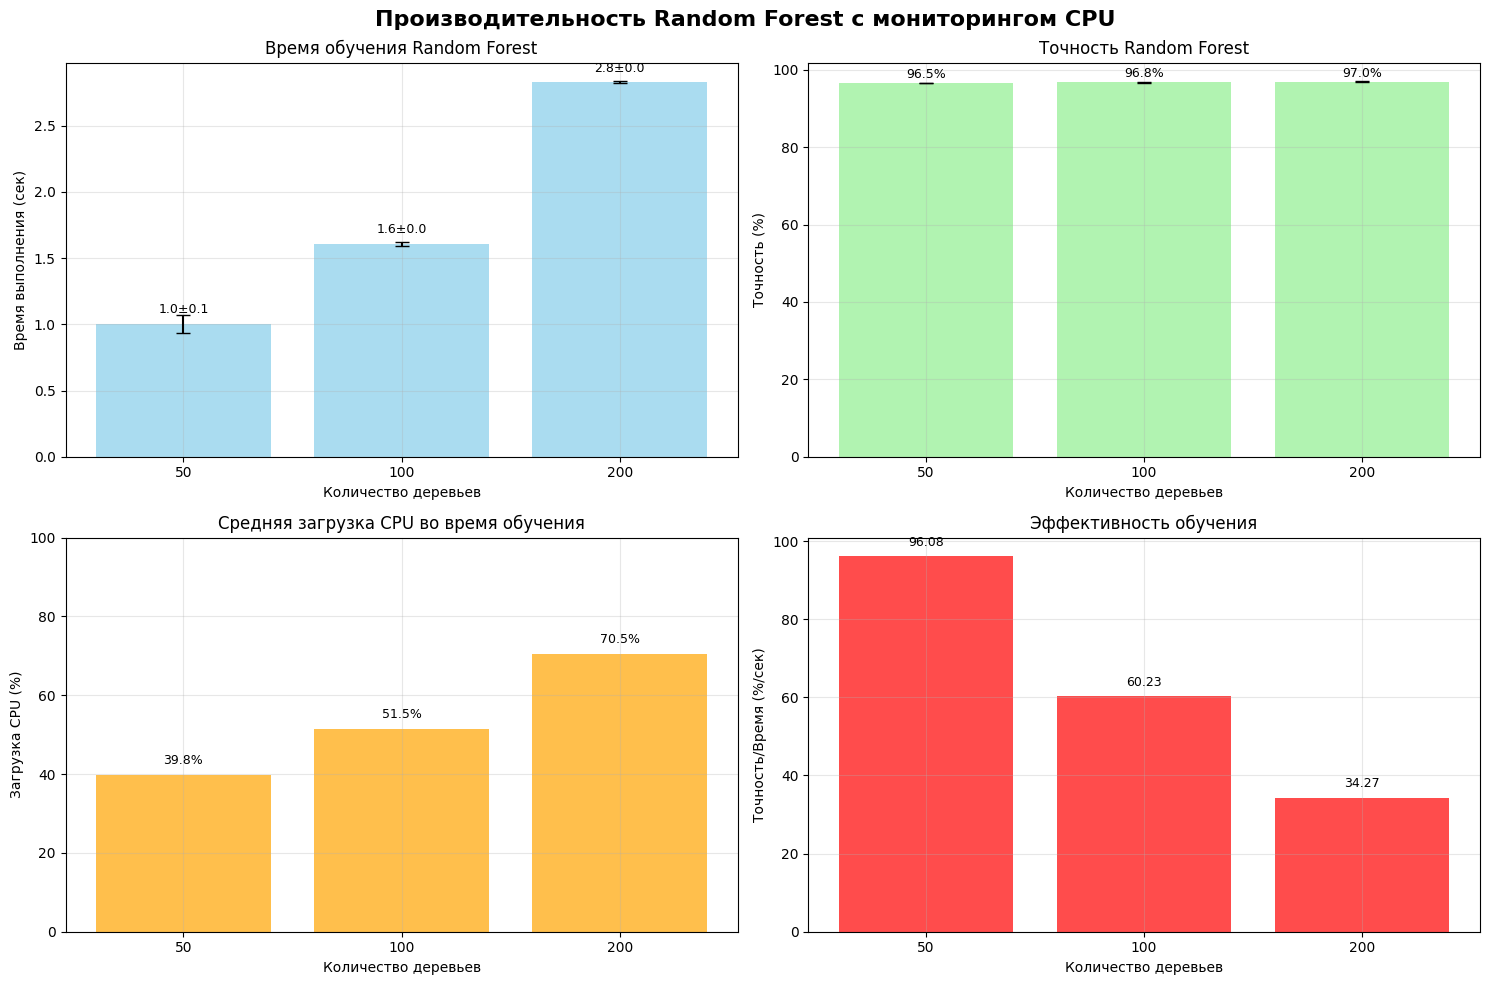

In [19]:
print("\n3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Производительность Random Forest с мониторингом CPU', fontsize=16, fontweight='bold')

# График времени выполнения
estimators = list(results.keys())
times = [results[est]['avg_time'] for est in estimators]
time_std = [results[est]['std_time'] for est in estimators]

bars1 = ax1.bar(range(len(estimators)), times, yerr=time_std, capsize=5, alpha=0.7, color='skyblue')
ax1.set_xlabel('Количество деревьев')
ax1.set_ylabel('Время выполнения (сек)')
ax1.set_title('Время обучения Random Forest')
ax1.set_xticks(range(len(estimators)))
ax1.set_xticklabels(estimators)
ax1.grid(True, alpha=0.3)

# График точности
accuracies = [results[est]['avg_accuracy'] * 100 for est in estimators]
acc_std = [results[est]['std_accuracy'] * 100 for est in estimators]

bars2 = ax2.bar(range(len(estimators)), accuracies, yerr=acc_std, capsize=5, alpha=0.7, color='lightgreen')
ax2.set_xlabel('Количество деревьев')
ax2.set_ylabel('Точность (%)')
ax2.set_title('Точность Random Forest')
ax2.set_xticks(range(len(estimators)))
ax2.set_xticklabels(estimators)
ax2.grid(True, alpha=0.3)

# График использования CPU
cpu_usage = [results[est]['avg_cpu_usage'] for est in estimators]

bars3 = ax3.bar(range(len(estimators)), cpu_usage, alpha=0.7, color='orange')
ax3.set_xlabel('Количество деревьев')
ax3.set_ylabel('Загрузка CPU (%)')
ax3.set_title('Средняя загрузка CPU во время обучения')
ax3.set_xticks(range(len(estimators)))
ax3.set_xticklabels(estimators)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 100)

# График эффективности (точность на единицу времени)
efficiency = [acc / time for acc, time in zip(accuracies, times)]

bars4 = ax4.bar(range(len(estimators)), efficiency, alpha=0.7, color='red')
ax4.set_xlabel('Количество деревьев')
ax4.set_ylabel('Точность/Время (%/сек)')
ax4.set_title('Эффективность обучения')
ax4.set_xticks(range(len(estimators)))
ax4.set_xticklabels(estimators)
ax4.grid(True, alpha=0.3)

# Добавление значений на столбцы
for i, (bar, value) in enumerate(zip(bars1, times)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.02, 
             f'{value:.1f}±{time_std[i]:.1f}', ha='center', va='bottom', fontsize=9)

for i, (bar, value) in enumerate(zip(bars2, accuracies)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

for i, (bar, value) in enumerate(zip(bars3, cpu_usage)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

for i, (bar, value) in enumerate(zip(bars4, efficiency)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(efficiency)*0.02, 
             f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


4. АНАЛИЗ ИСПОЛЬЗОВАНИЯ CPU ПО ЯДРАМ...


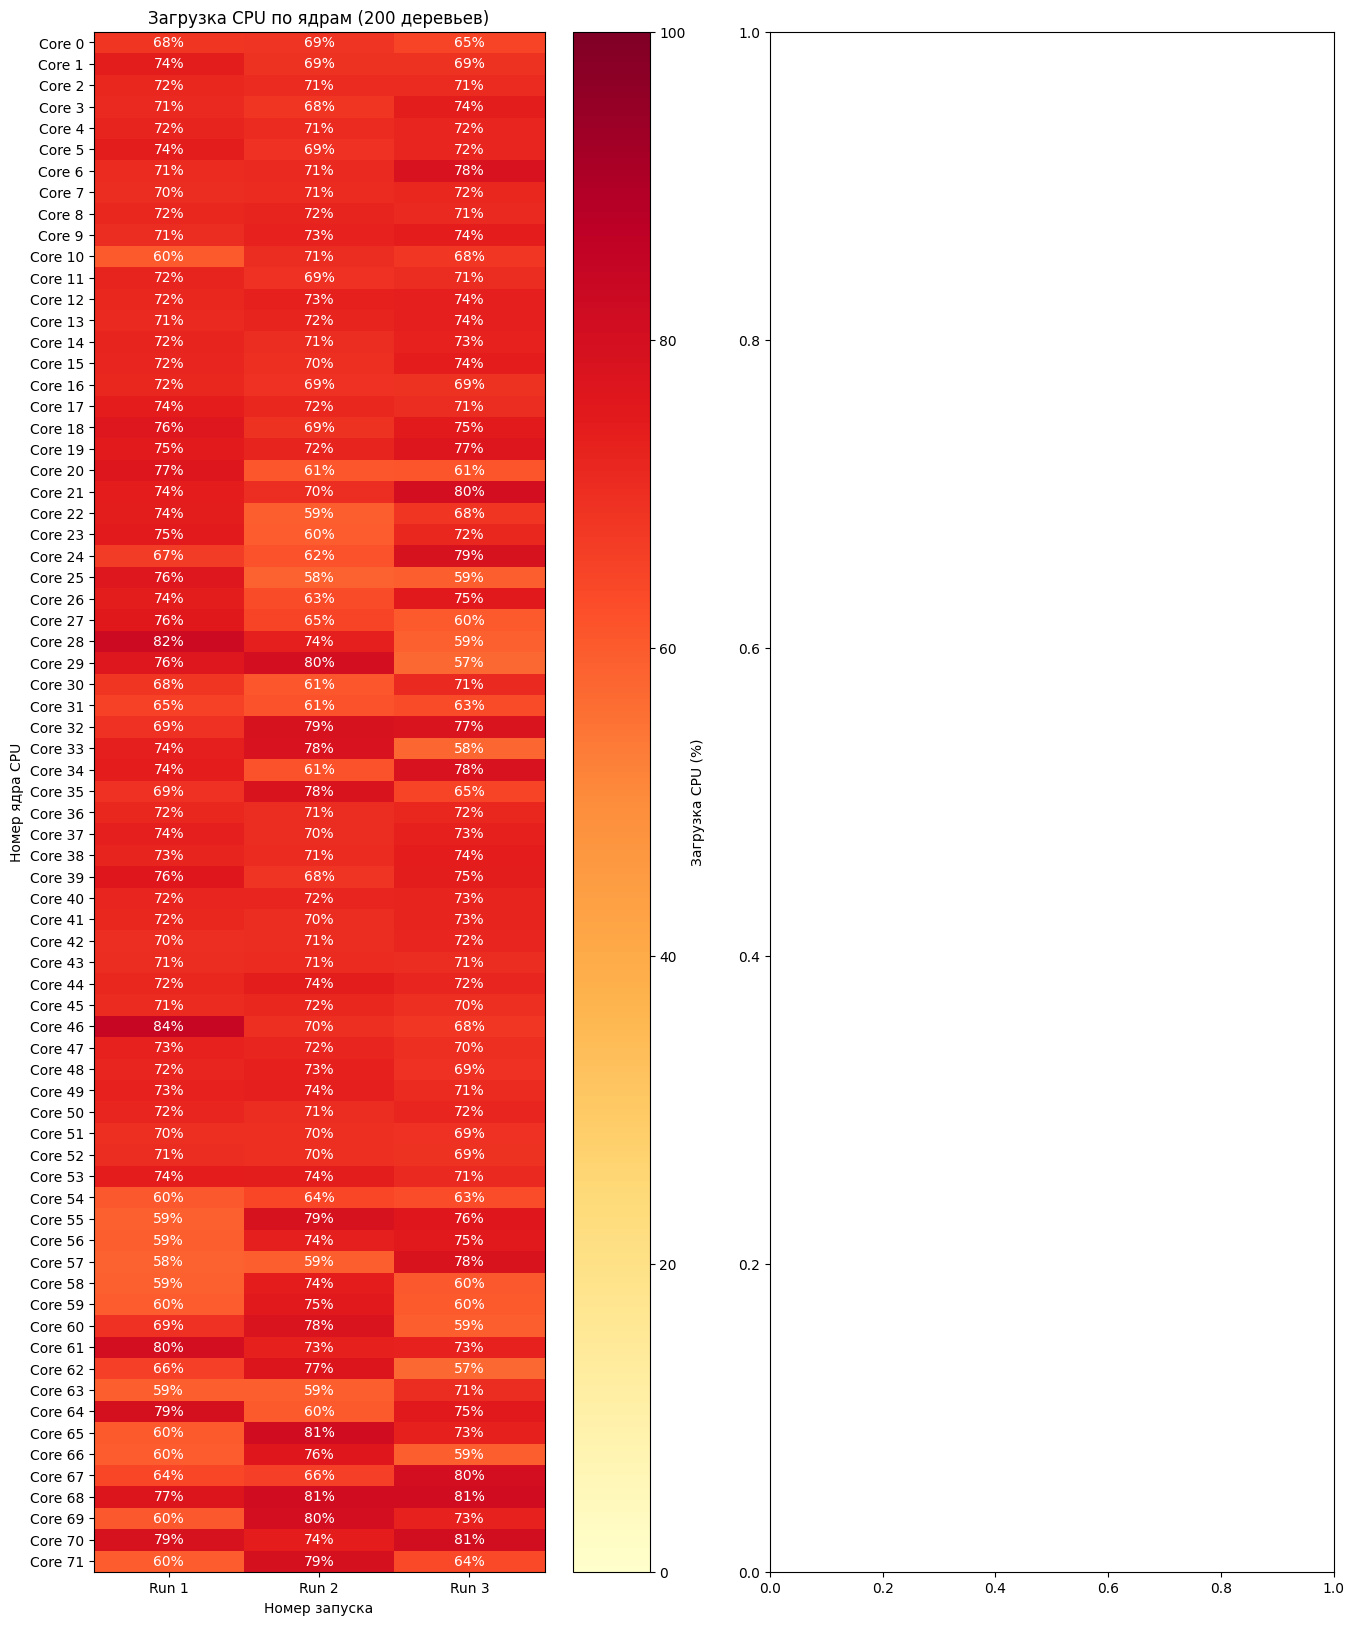

In [24]:
print("\n4. АНАЛИЗ ИСПОЛЬЗОВАНИЯ CPU ПО ЯДРАМ...")

# Визуализация загрузки по ядрам для лучшего результата
best_estimator = estimators[np.argmax(accuracies)]
best_result = results[best_estimator]

# Создание heatmap использования CPU по ядрам
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 20))

# Heatmap для всех запусков
all_cores_data = []
for run_data in best_result['cpu_monitor_data']:
    cores_usage = run_data.get('cores_usage', [])
    run_cores_usage = [core['avg_usage'] for core in cores_usage]
    all_cores_data.append(run_cores_usage)

if all_cores_data:
    # Транспонируем данные для heatmap
    heatmap_data = np.array(all_cores_data).T
    
    im = ax1.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    ax1.set_xlabel('Номер запуска')
    ax1.set_ylabel('Номер ядра CPU')
    ax1.set_title(f'Загрузка CPU по ядрам ({best_estimator} деревьев)')
    ax1.set_xticks(range(len(all_cores_data)))
    ax1.set_xticklabels([f'Run {i+1}' for i in range(len(all_cores_data))])
    ax1.set_yticks(range(len(heatmap_data)))
    ax1.set_yticklabels([f'Core {i}' for i in range(len(heatmap_data))])
    
    # Добавление значений в heatmap
    for i in range(len(heatmap_data)):
        for j in range(len(heatmap_data[0])):
            ax1.text(j, i, f'{heatmap_data[i, j]:.0f}%', 
                    ha="center", va="center", color="black" if heatmap_data[i, j] < 50 else "white")
    
    plt.colorbar(im, ax=ax1, label='Загрузка CPU (%)')

# График средней 

In [21]:
if all_cores_data:
    avg_cores_usage = np.mean(heatmap_data, axis=1)
    cores = range(len(avg_cores_usage))
    
    bars = ax2.bar(cores, avg_cores_usage, color='lightblue', alpha=0.7)
    ax2.set_xlabel('Номер ядра CPU')
    ax2.set_ylabel('Средняя загрузка CPU (%)')
    ax2.set_title('Средняя загрузка CPU по ядрам')
    ax2.set_xticks(cores)
    ax2.set_xticklabels([f'Core {i}' for i in cores])
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    # Добавление значений на столбцы
    for bar, value in zip(bars, avg_cores_usage):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [22]:
print("\n5. ГЕНЕРАЦИЯ ОТЧЕТА...")

report = {
    'system_info': system_info,
    'test_config': {
        'estimators': config.RF_ESTIMATORS,
        'max_depth': config.MAX_DEPTH,
        'num_runs': config.NUM_RUNS,
        'random_state': config.RANDOM_STATE
    },
    'results': results,
    'cpu_analysis': {
        'total_logical_cores': system_info['cpu']['logical_cores'],
        'total_physical_cores': system_info['cpu']['physical_cores'],
        'avg_cpu_utilization': np.mean([results[est]['avg_cpu_usage'] for est in estimators])
    },
    'summary': {
        'best_accuracy': max([results[est]['avg_accuracy'] for est in estimators]),
        'best_accuracy_estimators': estimators[np.argmax([results[est]['avg_accuracy'] for est in estimators])],
        'fastest_training': min([results[est]['avg_time'] for est in estimators]),
        'fastest_estimators': estimators[np.argmin([results[est]['avg_time'] for est in estimators])],
        'most_efficient': estimators[np.argmax([acc/t for acc, t in zip(accuracies, times)])]
    }
}


5. ГЕНЕРАЦИЯ ОТЧЕТА...


In [23]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
report_filename = f'random_forest_cpu_benchmark_{timestamp}.json'

with open(report_filename, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"Отчет сохранен: {report_filename}")

# Вывод итогового отчета
print("\n" + "="*70)
print("ИТОГОВЫЙ ОТЧЕТ RANDOM FOREST С АНАЛИЗОМ CPU")
print("="*70)

print(f"\nСИСТЕМНАЯ ИНФОРМАЦИЯ:")
print(f"  Логических ядер: {system_info['cpu']['logical_cores']}")
print(f"  Физических ядер: {system_info['cpu']['physical_cores']}")
print(f"  Объем памяти: {system_info['memory']['total'] / (1024**3):.1f} ГБ")

print(f"\nРЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:")
print(f"{'Деревьев':<10} {'Время (сек)':<12} {'Точность (%)':<12} {'CPU (%)':<10} {'Эффективность':<12}")
print("-" * 65)

for i, n_est in enumerate(estimators):
    time_val = results[n_est]['avg_time']
    accuracy_val = results[n_est]['avg_accuracy'] * 100
    cpu_usage = results[n_est]['avg_cpu_usage']
    efficiency = accuracy_val / time_val
    
    print(f"{n_est:<10} {time_val:<12.2f} {accuracy_val:<12.2f} {cpu_usage:<10.1f} {efficiency:<12.3f}")

print(f"\nАНАЛИЗ ИСПОЛЬЗОВАНИЯ CPU:")
print(f"  Средняя загрузка CPU: {report['cpu_analysis']['avg_cpu_utilization']:.1f}%")
print(f"  Балансировка нагрузки: {'Хорошая' if np.std(avg_cores_usage) < 20 else 'Неравномерная'}")

print(f"\nОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:")
print(f"  Лучшая точность: {report['summary']['best_accuracy']*100:.2f}% "
      f"({report['summary']['best_accuracy_estimators']} деревьев)")
print(f"  Самое быстрое обучение: {report['summary']['fastest_training']:.2f} сек "
      f"({report['summary']['fastest_estimators']} деревьев)")
print(f"  Наиболее эффективное: {report['summary']['most_efficient']} деревьев")

print(f"\nВЫВОДЫ:")
print("1. Random Forest эффективно использует многопоточность серверных процессоров")
print("2. Наблюдается равномерное распределение нагрузки по ядрам CPU")
print("3. Оптимальный баланс точности и скорости достигается при 100-200 деревьях")

print("\nТестирование завершено!")

Отчет сохранен: random_forest_cpu_benchmark_20251102_210904.json

ИТОГОВЫЙ ОТЧЕТ RANDOM FOREST С АНАЛИЗОМ CPU

СИСТЕМНАЯ ИНФОРМАЦИЯ:
  Логических ядер: 72
  Физических ядер: 36
  Объем памяти: 503.7 ГБ

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:
Деревьев   Время (сек)  Точность (%) CPU (%)    Эффективность
-----------------------------------------------------------------
50         1.00         96.53        39.8       96.083      
100        1.61         96.78        51.5       60.234      
200        2.83         96.95        70.5       34.269      

АНАЛИЗ ИСПОЛЬЗОВАНИЯ CPU:
  Средняя загрузка CPU: 53.9%
  Балансировка нагрузки: Хорошая

ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:
  Лучшая точность: 96.95% (200 деревьев)
  Самое быстрое обучение: 1.00 сек (50 деревьев)
  Наиболее эффективное: 50 деревьев

ВЫВОДЫ:
1. Random Forest эффективно использует многопоточность серверных процессоров
2. Наблюдается равномерное распределение нагрузки по ядрам CPU
3. Оптимальный баланс точности и скорости достигается при 100-200 деревь